In [7]:
import os
import shutil

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

# Use the GPU if one is actually available on this machine, otherwise fall
# back to the CPU (avoids JAX's noisy CUDA plugin init error when there's no GPU)
if shutil.which("nvidia-smi") is None:
    os.environ["JAX_PLATFORMS"] = "cpu"

In [8]:
from gaussian import Gaussian

from jax import vmap
import jax.numpy as jnp

import matplotlib.pyplot as plt

In [9]:
mu = jnp.array([1.0, 2.0])
Sigma = jnp.array(
    [
        [1.0, 0.5],
        [0.5, 2.0],
    ]
)

G = Gaussian(mu=mu, Sigma=Sigma)
G

Gaussian(mu=Array([1., 2.], dtype=float32), Sigma=Array([[1. , 0.5],
       [0.5, 2. ]], dtype=float32))

In [10]:
from matplotlib.colors import LinearSegmentedColormap
from tueplots.constants.color import rgb

cmp_wd = LinearSegmentedColormap.from_list("wd", ["w", rgb.tue_dark], N=1024)

X, Y = jnp.mgrid[-2:4:200j, -2:4:200j]
nplot = X.shape[0]
XY = jnp.dstack((X, Y)).reshape(nplot**2, 2)
XY
Z = vmap(G.pdf)(XY).reshape(nplot, nplot)
Z

Array([[2.2410441e-04, 2.3390718e-04, 2.4401190e-04, ..., 4.5485303e-05,
        4.2856940e-05, 4.0359439e-05],
       [2.3996850e-04, 2.5053066e-04, 2.6142132e-04, ..., 5.1262283e-05,
        4.8312584e-05, 4.5508994e-05],
       [2.5668912e-04, 2.6805623e-04, 2.7978155e-04, ..., 5.7712736e-05,
        5.4406082e-05, 5.1262185e-05],
       ...,
       [3.0991876e-07, 3.4045775e-07, 3.7381056e-07, ..., 1.5009271e-03,
        1.4884396e-03, 1.4752890e-03],
       [2.7043663e-07, 2.9716159e-07, 3.2635819e-07, ..., 1.3784746e-03,
        1.3673599e-03, 1.3556320e-03],
       [2.3573824e-07, 2.5910245e-07, 2.8463350e-07, ..., 1.2646959e-03,
        1.2548253e-03, 1.2443858e-03]], dtype=float32)

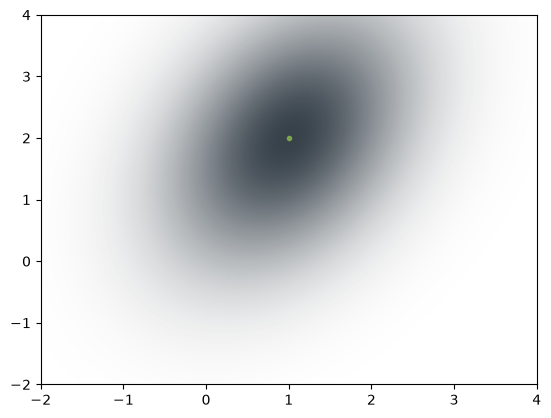

In [11]:
fig, ax = plt.subplots()
ax.contourf(X, Y, Z, levels=200, cmap=cmp_wd)
ax.plot(mu[0], mu[1], "o", color=rgb.tue_green, markersize=3)

In [12]:
mu = jnp.array([1.0, 2.0, 3.0])
Sigma = jnp.array(
    [
        [1.0, 0.5, 0.0],
        [0.5, 2.0, 0.0],
        [0.0, 0.0, 3.0],
    ]
)
g1 = Gaussian(mu=mu, Sigma=Sigma)
g2 = Gaussian(mu=mu, Sigma=Sigma)

g3 = g1 * g2
g3

Gaussian(mu=Array([1.       , 2.0000002, 3.       ], dtype=float32), Sigma=Array([[0.5 , 0.25, 0.  ],
       [0.25, 1.  , 0.  ],
       [0.  , 0.  , 1.5 ]], dtype=float32))

In [13]:
g4 = g1 + 3
g4

Gaussian(mu=Array([4., 5., 6.], dtype=float32), Sigma=Array([[1. , 0.5, 0. ],
       [0.5, 2. , 0. ],
       [0. , 0. , 3. ]], dtype=float32))

In [14]:
A = jnp.array(
    [
        [1, 2, 3],
        [1, 2, 3],
    ]
)
g5 = A @ g1
g5

Gaussian(mu=Array([14., 14.], dtype=float32), Sigma=Array([[38., 38.],
       [38., 38.]], dtype=float32))

In [15]:
g1[0], g1[1], g1[2]

(Gaussian(mu=Array(1., dtype=float32), Sigma=Array(1., dtype=float32)),
 Gaussian(mu=Array(2., dtype=float32), Sigma=Array(2., dtype=float32)),
 Gaussian(mu=Array(3., dtype=float32), Sigma=Array(3., dtype=float32)))

In [16]:
g1 + g2

Gaussian(mu=Array([2., 4., 6.], dtype=float32), Sigma=Array([[2., 1., 0.],
       [1., 4., 0.],
       [0., 0., 6.]], dtype=float32))

In [ ]:
A = jnp.array(
    [
        [1, 1, 0],
        [0, 2, 1],
    ]
)
Lambda = 0.2 * jnp.eye(2)
y = jnp.array([1, 2])